# Boston Housing Violations — v3 (more features, more models, tuning)

Builds on `modeling_v2.ipynb`. Same parcel-grouped CV and held-out test, so numbers are directly comparable.

**What's new vs. v2:**
- **Engineered features**: `property_age` from `YR_BUILT`; `OWN_OCC` (owner-occupied flag); `ward`; `code` (target-encoded); `month`, `weekday`, `year` from `status_dttm`.
- **5th model: LightGBM** — usually competitive with XGBoost on tabular data, often better on mixed numeric + categorical.
- **Hyperparameter tuning** of the best gradient booster via `HalvingRandomSearchCV` (much faster than full GridSearch).
- **VotingClassifier** soft-vote ensemble of the strongest individual models.
- Dropped `class_weight='balanced'` from RF/LR — it was inverting predictions and tanking F1 without helping ROC-AUC.


## 1. Setup

In [1]:
# Bootstrap: install xgboost + lightgbm into user site-packages if missing.
import importlib, subprocess, sys
for pkg in ('xgboost', 'lightgbm'):
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', '--quiet', pkg])
importlib.invalidate_caches()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

## 2. Load data

In [2]:
USECOLS = [
    'case_no', 'PARCEL', 'POINT_X', 'POINT_Y', 'YR_BUILT',
    'MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND',
    'description', 'OWNER',
    # New in v3:
    'OWN_OCC', 'ward', 'code', 'status_dttm',
]
df = pd.read_csv('merged_violations.csv', usecols=USECOLS, parse_dates=['status_dttm'])
print('Raw shape:', df.shape)
df.head(3)

Raw shape: (17075, 15)


,case_no,status_dttm,code,description,ward,MAILING_NEIGHBORHOOD,PARCEL,POINT_X,POINT_Y,OWNER,YR_BUILT,LU_DESC,BLDG_TYPE,OWN_OCC,OVERALL_COND
0,V91983,NaT,121.2,Unsafe and Dangerous,1,East Boston,104910000.0,-71.036580,42.367679,ORELLANA-SERRANO ISRAEL,1930.0,THREE-FAM DWELLING,RM - Row Middle,Y,A - Average
1,V898855,2026-03-25 10:13:31,105.1,Failure to Obtain Permit,3,Roxbury,306337000.0,-71.064197,42.345034,345 HARRISON LLC,2016.0,RES /COMMERCIAL USE,120 - LUXURY APARTMENT,N,EX - Excellent
2,V898828,2026-03-25 09:20:39,105.1,Failure to Obtain Permit,3,Roxbury,306626000.0,-71.061720,42.345440,217 ALBANY II LLC,2020.0,LUXURY APARTMENT,114 - APT 100+ UNITS,N,VG - Very Good


## 3. Target & feature engineering

Same target as v2: `repeat_violation = 1` if a parcel appears in more than one violation record.

New engineered features:
- `property_age` — current year minus `YR_BUILT`. Direct numeric signal that linear models can use without bin-finding.
- `month` / `weekday` / `year` from `status_dttm` — capture seasonality and time trend.
- `OWN_OCC` — owner-occupied (Y/N). Owner-occupied parcels have a different repeat-violation profile (~50% vs ~64%).
- `ward` — Boston ward. Repeat rate ranges from 46% to 69% across wards — strong signal.
- `code` — fine-grained violation code (503 unique values), target-encoded so it doesn't blow up dimensionality.

In [3]:
df = df.dropna(subset=['PARCEL']).reset_index(drop=True)
df['repeat_violation'] = (df.groupby('PARCEL')['case_no'].transform('count') > 1).astype(int)

# Engineered features
CURRENT_YEAR = 2026
df['property_age'] = (CURRENT_YEAR - df['YR_BUILT']).clip(lower=0)
df['month']   = df['status_dttm'].dt.month
df['weekday'] = df['status_dttm'].dt.weekday
df['year']    = df['status_dttm'].dt.year

print('Rows after dropna:', len(df))
print('Class balance:')
print(df['repeat_violation'].value_counts(normalize=True).round(3))

Rows after dropna: 16277
Class balance:
repeat_violation
1    0.604
0    0.396
Name: proportion, dtype: float64


In [4]:
num_features  = ['POINT_X', 'POINT_Y', 'YR_BUILT', 'property_age',
                 'month', 'weekday', 'year']
low_card_cat  = ['MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND',
                 'OWN_OCC', 'ward']
high_card_cat = ['OWNER', 'description', 'code']  # all target-encoded

feature_cols = num_features + low_card_cat + high_card_cat
X = df[feature_cols].copy()
y = df['repeat_violation'].values
groups = df['PARCEL']

# Fill missing values. Numerical: median. Categorical: explicit token (cast to str so
# OWN_OCC/ward/code don't carry mixed dtypes through the encoders).
X[num_features] = X[num_features].fillna(X[num_features].median())
for c in low_card_cat + high_card_cat:
    X[c] = X[c].fillna('__missing__').astype(str)

print('X shape:', X.shape, '   positive rate:', y.mean().round(3))

X shape: (16277, 16)    positive rate: 0.604


## 4. Preprocessor

Same shape as v2: numeric → standardize; low-cardinality categoricals → dense one-hot with rare categories collapsed; high-cardinality → fold-aware target encoding.

`sparse_output=False` on the OHE so HistGradientBoosting (dense-only) works through the same preprocessor.

In [5]:
preprocessor = ColumnTransformer([
    ('num',       StandardScaler(),                                                            num_features),
    ('low_card',  OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False), low_card_cat),
    ('high_card', TargetEncoder(target_type='binary', smooth='auto', random_state=RANDOM_STATE), high_card_cat),
])

## 5. Train / test split + CV setup

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups.iloc[train_idx]

print(f'Train: {len(X_train):>6} rows / {groups_train.nunique():>5} parcels')
print(f'Test : {len(X_test):>6} rows / {groups.iloc[test_idx].nunique():>5} parcels')

cv = GroupKFold(n_splits=5)

def cv_eval(name, model):
    scoring = {'roc_auc': 'roc_auc', 'ap': 'average_precision', 'f1': 'f1'}
    # n_jobs=1 here so we don't nest parallelism with the inner model's n_jobs=-1.
    s = cross_validate(model, X_train, y_train, cv=cv, groups=groups_train,
                       scoring=scoring, n_jobs=1)
    return {
        'model'   : name,
        'roc_auc' : s['test_roc_auc'].mean(),
        'auc_std' : s['test_roc_auc'].std(),
        'pr_auc'  : s['test_ap'].mean(),
        'f1'      : s['test_f1'].mean(),
    }

Train:  12990 rows /  7828 parcels
Test :   3287 rows /  1958 parcels


## 6. Five baseline models (with new features)

Same four as v2 plus LightGBM. **Class weighting removed** from LR/RF — it was pushing predictions toward the minority class and tanking F1 without improving ROC-AUC.

In [7]:
lr = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

rf = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                    n_jobs=-1, random_state=RANDOM_STATE)),
])

hgb = Pipeline([
    ('prep', preprocessor),
    ('clf',  HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06,
                                            max_leaf_nodes=63,
                                            random_state=RANDOM_STATE)),
])

xgb = Pipeline([
    ('prep', preprocessor),
    ('clf',  XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        min_child_weight=2, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, objective='binary:logistic', eval_metric='auc',
        tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE,
    )),
])

lgb = Pipeline([
    ('prep', preprocessor),
    ('clf',  LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, objective='binary', n_jobs=-1,
        random_state=RANDOM_STATE, verbose=-1,
    )),
])

models = {
    'Logistic Regression' : lr,
    'Random Forest'       : rf,
    'HistGradientBoosting': hgb,
    'XGBoost'             : xgb,
    'LightGBM'            : lgb,
}
results = [cv_eval(name, m) for name, m in models.items()]
results_df = pd.DataFrame(results).set_index('model').sort_values('roc_auc', ascending=False)
results_df.round(3)

/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt

,roc_auc,auc_std,pr_auc,f1
model,,,,
Logistic Regression,0.585,0.019,0.678,0.108
Random Forest,0.585,0.021,0.682,0.108
XGBoost,0.571,0.021,0.664,0.123
HistGradientBoosting,0.561,0.019,0.660,0.116
LightGBM,0.559,0.020,0.658,0.118


## 7. Held-out test on the CV winner (untuned)

In [8]:
best_name  = results_df.index[0]
best_model = models[best_name]
print('Best by CV ROC-AUC:', best_name)

best_model.fit(X_train, y_train)
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f'\n=== Held-out test ({best_name}, untuned) ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba):.3f}\n')
print(classification_report(y_test, y_pred, digits=3))
print('Confusion matrix [[TN FP][FN TP]]:')
print(confusion_matrix(y_test, y_pred))

Best by CV ROC-AUC: Logistic Regression

=== Held-out test (Logistic Regression, untuned) ===
ROC-AUC : 0.599
PR-AUC  : 0.698

              precision    recall  f1-score   support

           0      0.403     0.965     0.569      1281
           1      0.796     0.088     0.158      2006

    accuracy                          0.430      3287
   macro avg      0.600     0.526     0.363      3287
weighted avg      0.643     0.430     0.318      3287

Confusion matrix [[TN FP][FN TP]]:
[[1236   45]
 [1830  176]]


## 8. Hyperparameter tuning

Tune the best gradient booster with `HalvingRandomSearchCV`. Halving search starts wide on a small data subset and progressively eliminates losers — usually 5-10× faster than full grid/random search for similar coverage.

We tune on the training set with the same `GroupKFold` so parcels stay separated.

In [9]:
# Pick the best booster from the CV table to tune.
booster_candidates = ['XGBoost', 'LightGBM', 'HistGradientBoosting']
booster_name = next(n for n in results_df.index if n in booster_candidates)
print('Tuning:', booster_name)
booster_pipe = models[booster_name]

# Search space — keys must be prefixed with the pipeline step name (`clf__`).
if booster_name == 'XGBoost':
    param_dist = {
        'clf__n_estimators'    : [300, 500, 800],
        'clf__learning_rate'   : [0.03, 0.05, 0.1],
        'clf__max_depth'       : [4, 6, 8],
        'clf__min_child_weight': [1, 2, 5],
        'clf__subsample'       : [0.7, 0.85, 1.0],
        'clf__colsample_bytree': [0.7, 0.85, 1.0],
        'clf__reg_lambda'      : [0.5, 1.0, 5.0],
    }
elif booster_name == 'LightGBM':
    param_dist = {
        'clf__n_estimators'      : [300, 500, 800],
        'clf__learning_rate'     : [0.03, 0.05, 0.1],
        'clf__num_leaves'        : [31, 63, 127],
        'clf__min_child_samples' : [10, 20, 50],
        'clf__subsample'         : [0.7, 0.85, 1.0],
        'clf__colsample_bytree'  : [0.7, 0.85, 1.0],
        'clf__reg_lambda'        : [0.0, 1.0, 5.0],
    }
else:  # HistGradientBoosting
    param_dist = {
        'clf__max_iter'       : [200, 400, 800],
        'clf__learning_rate'  : [0.03, 0.06, 0.1],
        'clf__max_leaf_nodes' : [31, 63, 127],
        'clf__min_samples_leaf': [10, 20, 50],
        'clf__l2_regularization': [0.0, 1.0, 5.0],
    }

search = HalvingRandomSearchCV(
    booster_pipe, param_dist,
    factor=3, resource='n_samples',
    cv=cv, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=1, verbose=1,
)
search.fit(X_train, y_train, groups=groups_train)

print(f'\nBest CV ROC-AUC: {search.best_score_:.3f}')
print('Best params:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

tuned_model = search.best_estimator_

Tuning: XGBoost
n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 20
max_resources_: 12990
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 649
n_resources: 20
Fitting 5 folds for each of 649 candidates, totalling 3245 fits


/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025-pyt/lib/python3.12/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/share/pkg.8/academic-ml/fall-2025/install/fall-2025

----------
iter: 1
n_candidates: 217
n_resources: 60
Fitting 5 folds for each of 217 candidates, totalling 1085 fits
----------
iter: 2
n_candidates: 73
n_resources: 180
Fitting 5 folds for each of 73 candidates, totalling 365 fits
----------
iter: 3
n_candidates: 25
n_resources: 540
Fitting 5 folds for each of 25 candidates, totalling 125 fits
----------
iter: 4
n_candidates: 9
n_resources: 1620
Fitting 5 folds for each of 9 candidates, totalling 45 fits
----------
iter: 5
n_candidates: 3
n_resources: 4860
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best CV ROC-AUC: 0.586
Best params:
  clf__subsample: 1.0
  clf__reg_lambda: 5.0
  clf__n_estimators: 300
  clf__min_child_weight: 5
  clf__max_depth: 4
  clf__learning_rate: 0.05
  clf__colsample_bytree: 0.7


In [10]:
# Evaluate tuned model on the held-out test set.
y_pred_t  = tuned_model.predict(X_test)
y_proba_t = tuned_model.predict_proba(X_test)[:, 1]

print(f'=== Held-out test (tuned {booster_name}) ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_t):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_t):.3f}\n')
print(classification_report(y_test, y_pred_t, digits=3))
print('Confusion matrix [[TN FP][FN TP]]:')
print(confusion_matrix(y_test, y_pred_t))

=== Held-out test (tuned XGBoost) ===
ROC-AUC : 0.588
PR-AUC  : 0.686

              precision    recall  f1-score   support

           0      0.399     0.960     0.564      1281
           1      0.755     0.078     0.142      2006

    accuracy                          0.422      3287
   macro avg      0.577     0.519     0.353      3287
weighted avg      0.616     0.422     0.306      3287

Confusion matrix [[TN FP][FN TP]]:
[[1230   51]
 [1849  157]]


## 9. Voting ensemble

Soft-vote the three strongest individual models. Often picks up a small additional gain because the models make uncorrelated errors.

In [11]:
# Top 3 models from CV (excluding the tuned one if it's the same model — we add the tuned version separately).
top3_names = [n for n in results_df.index][:3]
print('Voting members (CV-untuned):', top3_names)

voting = VotingClassifier(
    estimators=[(name.replace(' ', '_'), models[name]) for name in top3_names],
    voting='soft',
    n_jobs=1,  # avoid nested parallelism with members' n_jobs=-1
)
voting.fit(X_train, y_train)
y_pred_v  = voting.predict(X_test)
y_proba_v = voting.predict_proba(X_test)[:, 1]

print(f'\n=== Held-out test (Voting top-3) ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_v):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba_v):.3f}\n')
print(classification_report(y_test, y_pred_v, digits=3))

Voting members (CV-untuned): ['Logistic Regression', 'Random Forest', 'XGBoost']

=== Held-out test (Voting top-3) ===
ROC-AUC : 0.622
PR-AUC  : 0.709

              precision    recall  f1-score   support

           0      0.399     0.964     0.565      1281
           1      0.762     0.073     0.134      2006

    accuracy                          0.420      3287
   macro avg      0.580     0.519     0.349      3287
weighted avg      0.620     0.420     0.302      3287



## 10. Final comparison + curves

In [12]:
summary = pd.DataFrame([
    {'model': f'{best_name} (untuned)',  'roc_auc': roc_auc_score(y_test, y_proba),   'pr_auc': average_precision_score(y_test, y_proba)},
    {'model': f'{booster_name} (tuned)', 'roc_auc': roc_auc_score(y_test, y_proba_t), 'pr_auc': average_precision_score(y_test, y_proba_t)},
    {'model': 'Voting top-3',            'roc_auc': roc_auc_score(y_test, y_proba_v), 'pr_auc': average_precision_score(y_test, y_proba_v)},
]).set_index('model').sort_values('roc_auc', ascending=False)
summary.round(3)

,roc_auc,pr_auc
model,,
Voting top-3,0.622,0.709
Logistic Regression (untuned),0.599,0.698
XGBoost (tuned),0.588,0.686


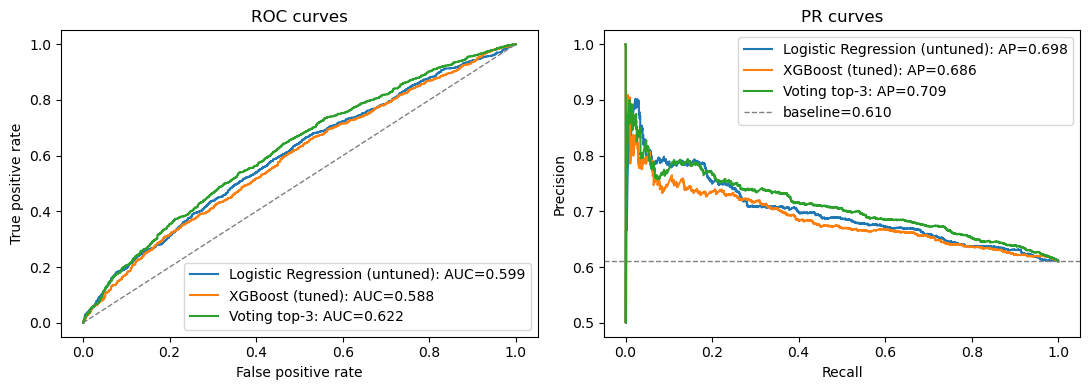

In [13]:
# ROC + PR curves for all three final models.
final_models = [
    (f'{best_name} (untuned)',  y_proba),
    (f'{booster_name} (tuned)', y_proba_t),
    ('Voting top-3',            y_proba_v),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, proba in final_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{label}: AUC={roc_auc_score(y_test, proba):.3f}')
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{label}: AP={average_precision_score(y_test, proba):.3f}')

axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves'); axes[0].legend()

axes[1].axhline(y_test.mean(), linestyle='--', color='gray', linewidth=1, label=f'baseline={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR curves'); axes[1].legend()

plt.tight_layout(); plt.show()

## 11. Permutation importance on the best final model

Importance for: Voting top-3


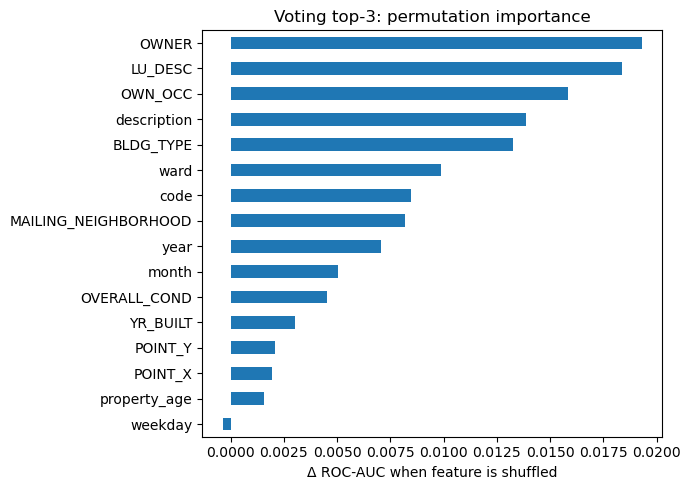

OWNER                   0.0193
LU_DESC                 0.0184
OWN_OCC                 0.0158
description             0.0139
BLDG_TYPE               0.0132
ward                    0.0099
code                    0.0085
MAILING_NEIGHBORHOOD    0.0082
year                    0.0071
month                   0.0050
OVERALL_COND            0.0045
YR_BUILT                0.0030
POINT_Y                 0.0021
POINT_X                 0.0019
property_age            0.0016
weekday                -0.0004
dtype: float64

In [14]:
# Pick whichever final model has the highest test ROC-AUC for importance analysis.
final_pick = summary.index[0]
if 'tuned' in final_pick:
    final_clf, final_proba = tuned_model, y_proba_t
elif 'Voting' in final_pick:
    final_clf, final_proba = voting, y_proba_v
else:
    final_clf, final_proba = best_model, y_proba

print('Importance for:', final_pick)
perm = permutation_importance(final_clf, X_test, y_test,
                              n_repeats=5, scoring='roc_auc',
                              random_state=RANDOM_STATE, n_jobs=1)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(7, 5))
importance.plot.barh()
plt.xlabel('Δ ROC-AUC when feature is shuffled')
plt.title(f'{final_pick}: permutation importance')
plt.tight_layout(); plt.show()

importance.sort_values(ascending=False).round(4)

## 12. Notes

- Compare the v3 numbers against v2: the headline metric is held-out **ROC-AUC**. v2's best was ~0.604.
- If the tuned booster wins by a clear margin, the engineered features + tuning paid off.
- If the voting ensemble wins by only a hair, individual models are agreeing — diminishing returns from stacking.
- If permutation importance for `month`/`weekday`/`year` is near zero, drop them; they're cheap but if they don't help, less surface area is better.
- **Next experiments worth trying** (not in this notebook to keep runtime sane):
  - **Stacking** with `StackingClassifier` and a logistic meta-learner.
  - **CatBoost** — handles `OWNER` natively, no encoding needed.
  - **Threshold tuning**: pick the operating point on the PR curve that matches whatever inspector workload is realistic, instead of using 0.5.